<a href="https://colab.research.google.com/github/lukwac123/computer_vision_course/blob/main/10_tensorflow-hub/02_classification_transfer_learning_current_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### <a name='a1'></a>Import bibliotek

In [9]:
import sys
import os
import json
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import PIL.Image as Image
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import tensorflow as tf
import keras

from keras import layers
from keras.applications.mobilenet_v2 import (
    MobileNetV2,
    preprocess_input,
)

print(f'Python version: {sys.version.split()[0]}')
print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {keras.__version__}')

print('\nGPU:')
print(tf.config.list_physical_devices('GPU'))

Python version: 3.13.15
TensorFlow version: 2.20.0
Keras version: 3.13.2

GPU:
[]


### <a name='a2'></a> Załadowanie modelu

In [10]:
IMAGE_SHAPE = (224, 224)

print('[INFO] Ładowanie MobileNetV2 wytrenowanego na ImageNet...')

classifier = MobileNetV2(
    weights='imagenet',
    include_top=True,
    input_shape=IMAGE_SHAPE + (3,)
)

print('[INFO] Model załadowany.')
print(f'[INFO] Wejście: {classifier.input_shape}')
print(f'[INFO] Wyjście: {classifier.output_shape}')

[INFO] Ładowanie MobileNetV2 wytrenowanego na ImageNet...
14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
[INFO] Model załadowany.
[INFO] Wejście: (None, 224, 224, 3)
[INFO] Wyjście: (None, 1000)


### <a name='a3'></a> Załadowanie etykiet

In [11]:
labels_path = keras.utils.get_file(
    'imagenet_class_index.json',
    'https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json'
)

with open(labels_path, 'r', encoding='utf-8') as file:
    class_index = json.load(file)

imagenet_labels = np.array([
    class_index[str(i)][1]
    for i in range(1000)
])

print(f'[INFO] Liczba etykiet ImageNet: {len(imagenet_labels)}')
imagenet_labels[:20]

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
[INFO] Liczba etykiet ImageNet: 1000


array(['tench', 'goldfish', 'great_white_shark', 'tiger_shark',
       'hammerhead', 'electric_ray', 'stingray', 'cock', 'hen', 'ostrich',
       'brambling', 'goldfinch', 'house_finch', 'junco', 'indigo_bunting',
       'robin', 'bulbul', 'jay', 'magpie', 'chickadee'], dtype='<U30')

### <a name='a4'></a> Załadowanie obrazu

In [12]:
from google.colab import files

uploaded = files.upload()

if not uploaded:
    raise RuntimeError('Nie wybrano żadnego obrazu.')

Saving 00000813.jpg to 00000813.jpg


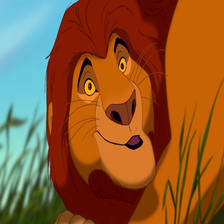

[INFO] Plik: 00000813.jpg
[INFO] Rozmiar: (224, 224)


In [13]:
filename = next(iter(uploaded.keys()))

img = Image.open(filename).convert('RGB')
img = img.resize(IMAGE_SHAPE, Image.Resampling.LANCZOS)

display(img)

print(f'[INFO] Plik: {filename}')
print(f'[INFO] Rozmiar: {img.size}')

### <a name='a5'></a> Predykcja na podstawie modelu

In [14]:
# MobileNetV2 wymaga preprocessing'u skalującego wartości pikseli
# z zakresu [0, 255] do [-1, 1].

img_arr = np.asarray(img, dtype=np.float32)
img_arr = np.expand_dims(img_arr, axis=0)
img_arr = preprocess_input(img_arr)

result = classifier.predict(img_arr, verbose=0)

predicted_class = int(np.argmax(result[0]))
predicted_class_name = imagenet_labels[predicted_class]
predicted_probability = float(result[0][predicted_class])

print(f'[INFO] Predykcja: {predicted_class_name}')
print(f'[INFO] Prawdopodobieństwo: {predicted_probability * 100:.2f}%')

top5_idxs = np.argsort(result[0])[::-1][:5]

top5 = pd.DataFrame({
    'class': [imagenet_labels[i] for i in top5_idxs],
    'probability [%]': [
        round(float(result[0][i]) * 100, 2)
        for i in top5_idxs
    ],
})

top5

[INFO] Predykcja: mask
[INFO] Prawdopodobieństwo: 13.14%


,class,probability [%]
0,mask,13.14
1,comic_book,6.25
2,balloon,4.82
3,pencil_sharpener,2.89
4,jack-o'-lantern,2.32


### <a name='a6'></a> Wyświetlenie predykcji

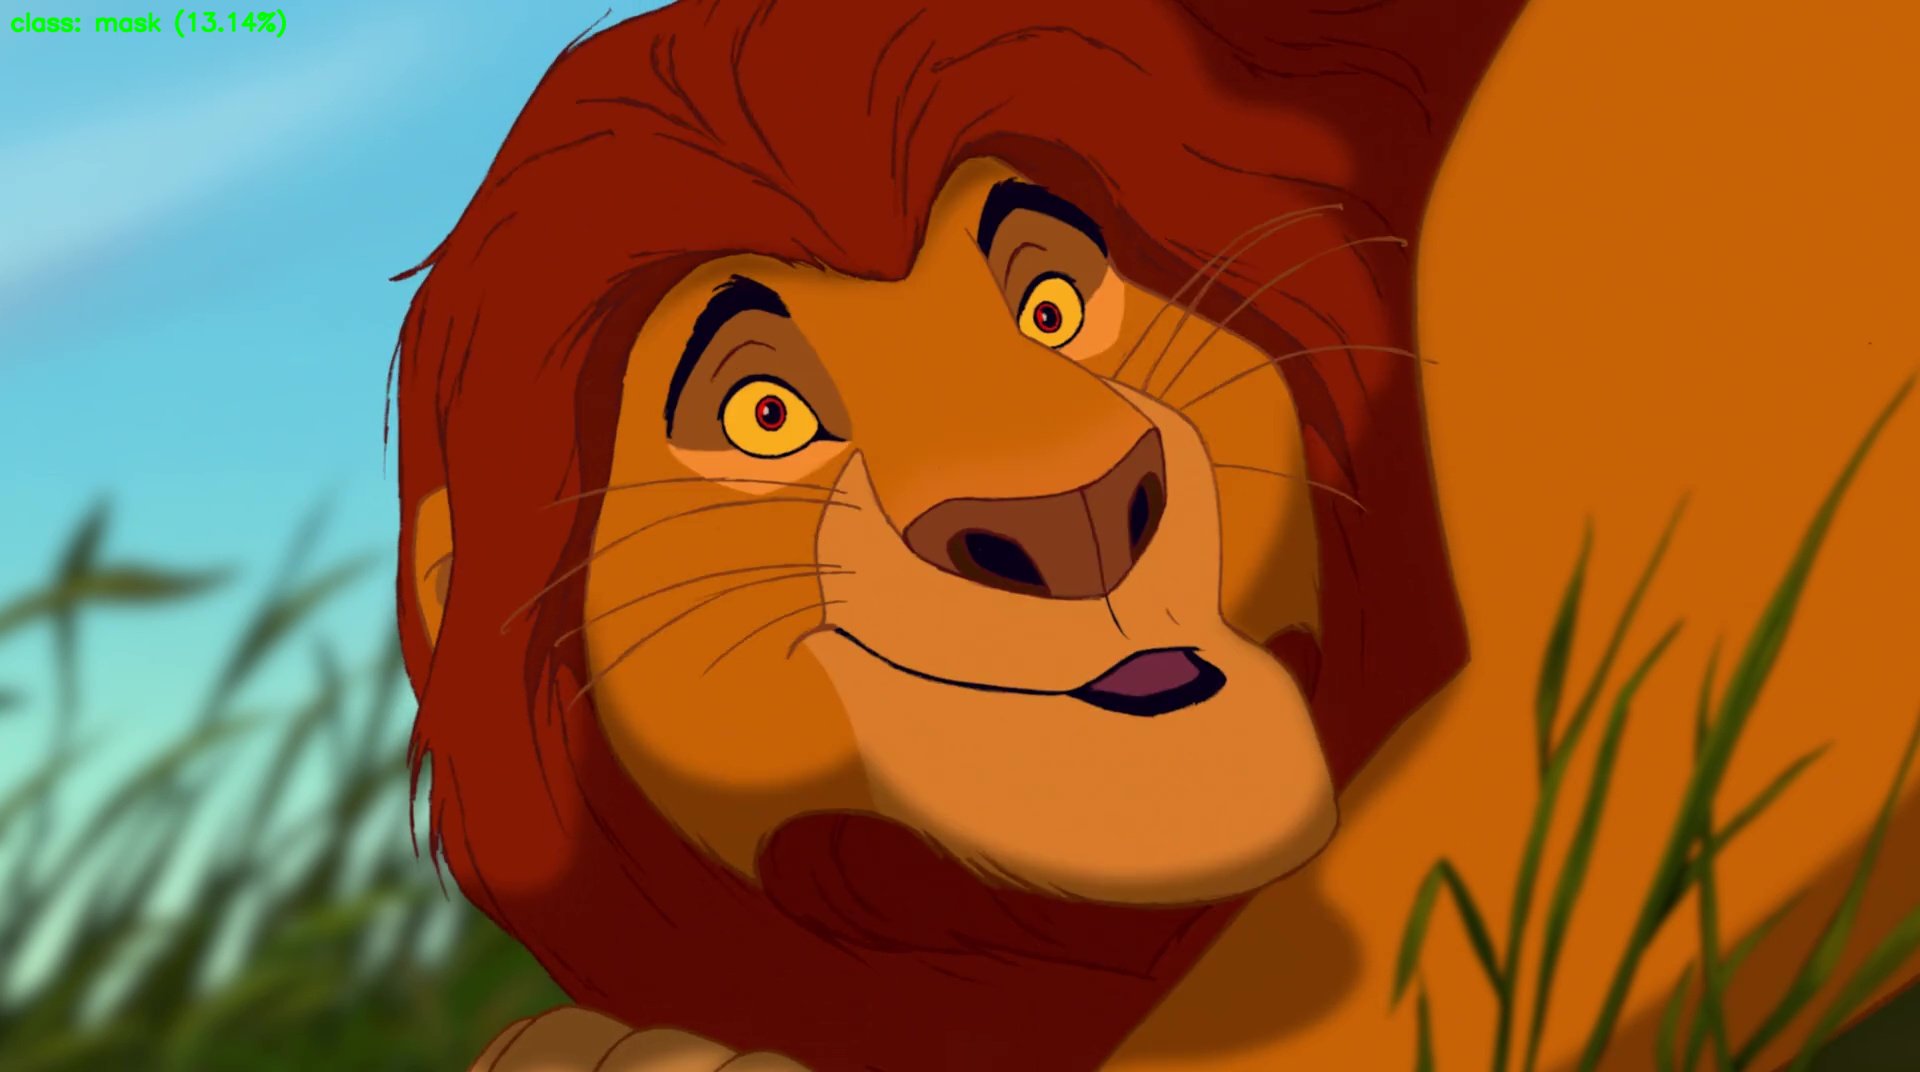

In [15]:
from google.colab.patches import cv2_imshow
import cv2

image_bgr = cv2.imread(filename)

if image_bgr is None:
    raise ValueError(f'Nie można wczytać obrazu: {filename}')

text = (
    f'class: {predicted_class_name} '
    f'({predicted_probability * 100:.2f}%)'
)

cv2.putText(
    img=image_bgr,
    text=text,
    org=(10, 30),
    fontFace=cv2.FONT_HERSHEY_SIMPLEX,
    fontScale=0.8,
    color=(0, 255, 0),
    thickness=2,
    lineType=cv2.LINE_AA
)

cv2_imshow(image_bgr)

###  <a name='a7'></a> Transfer Learning

In [16]:
DATASET_URL = (
    'https://storage.googleapis.com/'
    'esmartdata-courses-files/opencv-python/images.zip'
)

ARCHIVE_PATH = '/content/images.zip'
DATASET_DIR = '/content/images'

if not os.path.isdir(DATASET_DIR):
    print('[INFO] Pobieranie zbioru danych...')
    urllib.request.urlretrieve(DATASET_URL, ARCHIVE_PATH)

    print('[INFO] Rozpakowywanie...')
    with zipfile.ZipFile(ARCHIVE_PATH, 'r') as archive:
        archive.extractall('/content')

    print('[INFO] Dane przygotowane.')
else:
    print('[INFO] Katalog images już istnieje.')

print('[INFO] DATASET_DIR:', DATASET_DIR)

[INFO] Pobieranie zbioru danych...
[INFO] Rozpakowywanie...
[INFO] Dane przygotowane.
[INFO] DATASET_DIR: /content/images


In [17]:
BATCH_SIZE = 32
SEED = 10

# Keras 3: współczesny zamiennik ImageDataGenerator +
# flow_from_directory().
image_data = keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMAGE_SHAPE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

class_names = np.array(image_data.class_names)
num_classes = len(class_names)

print(f'[INFO] Klasy własnego zbioru: {class_names}')
print(f'[INFO] Liczba klas: {num_classes}')

# Przyspieszenie pipeline'u.
image_data = image_data.prefetch(tf.data.AUTOTUNE)

# Pobranie jednego wsadu.
image_batch, label_batch = next(iter(image_data))

print('Image batch shape:', image_batch.shape)
print('Label batch shape:', label_batch.shape)

# Predykcja pretrenowanego klasyfikatora ImageNet.
imagenet_batch = preprocess_input(
    tf.cast(image_batch, tf.float32)
)

result_batch = classifier.predict(
    imagenet_batch,
    verbose=0
)

predicted_class_names = imagenet_labels[
    np.argmax(result_batch, axis=-1)
]

predicted_class_names

Found 1113 files belonging to 2 classes.
[INFO] Klasy własnego zbioru: ['horse' 'lion']
[INFO] Liczba klas: 2
Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 2)


array(['sorrel', 'dhole', 'lion', 'Arabian_camel', 'lion', 'sorrel',
       'cowboy_boot', 'lion', 'coyote', 'teddy', 'sorrel', 'soccer_ball',
       'chimpanzee', 'lion', 'ram', 'shield', 'great_grey_owl',
       'chain_saw', 'Great_Dane', 'muzzle', 'Great_Dane', 'lion',
       'Mexican_hairless', 'Arabian_camel', 'lion',
       'flat-coated_retriever', 'Australian_terrier', 'lion', 'lion',
       'chow', 'hartebeest', 'sorrel'], dtype='<U30')

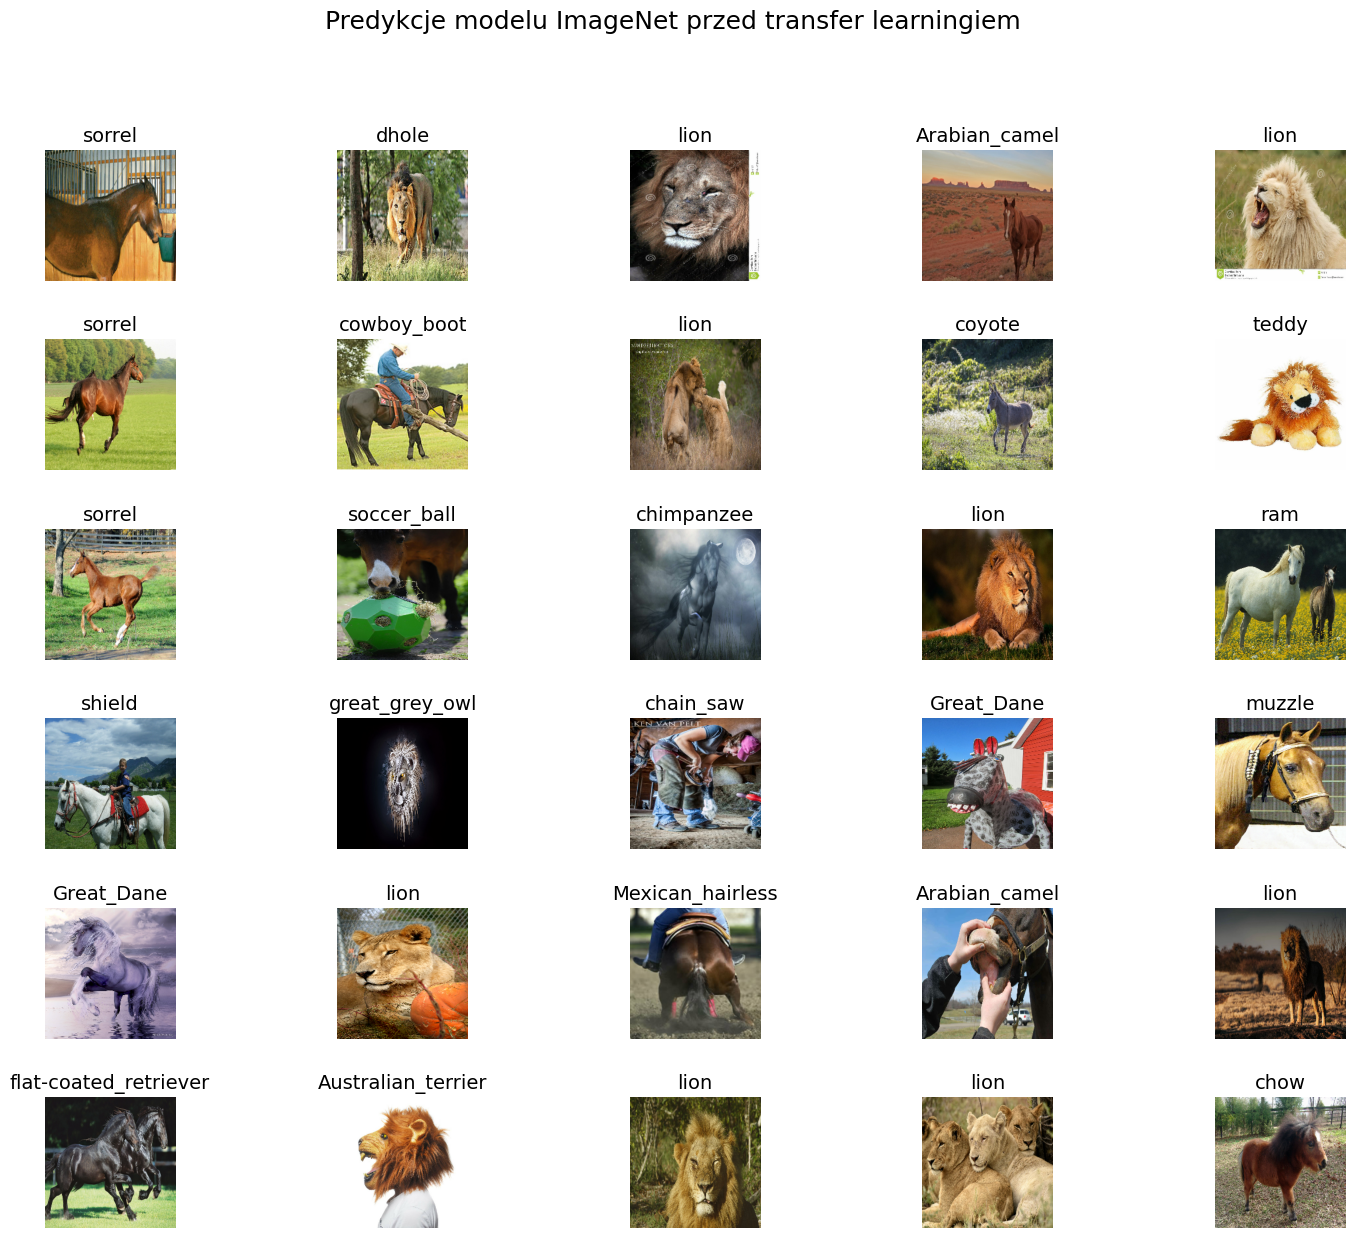

In [18]:
plt.figure(figsize=(18, 14))
plt.subplots_adjust(hspace=0.45, wspace=0.3)

n_images = min(30, image_batch.shape[0])

for n in range(n_images):
    plt.subplot(6, 5, n + 1)

    image_np = image_batch[n].numpy().astype('uint8')

    plt.imshow(image_np)
    plt.title(
        predicted_class_names[n],
        fontsize=14
    )
    plt.axis('off')

plt.suptitle(
    'Predykcje modelu ImageNet przed transfer learningiem',
    fontsize=18
)

plt.show()

Wykorzystamy teraz **ekstraktor cech MobileNetV2**, czyli model bez oryginalnej
warstwy klasyfikacyjnej ImageNet. Wagi ekstraktora zamrażamy, a następnie dokładamy
nową warstwę `Dense`, której liczba wyjść odpowiada klasom naszego zbioru.

Jest to klasyczny transfer learning: uczymy tylko nową głowicę klasyfikacyjną,
korzystając z cech wyuczonych wcześniej na ImageNet.

In [19]:
print('[INFO] Budowa ekstraktora cech MobileNetV2...')

feature_extractor = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=IMAGE_SHAPE + (3,),
    pooling='avg'
)

# Zamrażamy wagi modelu bazowego.
feature_extractor.trainable = False

inputs = keras.Input(
    shape=IMAGE_SHAPE + (3,),
    name='image'
)

# Odpowiednik preprocess_input() wewnątrz modelu:
# [0, 255] -> [-1, 1]
x = layers.Rescaling(
    scale=1.0 / 127.5,
    offset=-1.0,
    name='mobilenet_preprocessing'
)(inputs)

# training=False jest istotne m.in. dla BatchNormalization
# w zamrożonym modelu bazowym.
x = feature_extractor(
    x,
    training=False
)

outputs = layers.Dense(
    num_classes,
    activation='softmax',
    name='classifier'
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name='mobilenetv2_transfer_learning'
)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='categorical_crossentropy',
    metrics=[
        keras.metrics.CategoricalAccuracy(
            name='accuracy'
        )
    ]
)

model.summary()

[INFO] Budowa ekstraktora cech MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_preprocessing         │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 1280)           │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [20]:
# Callback rejestrujący stratę i dokładność po każdym batchu.
class CollectBatchStats(keras.callbacks.Callback):

    def __init__(self):
        super().__init__()
        self.batch_losses = []
        self.batch_acc = []

    def on_train_batch_end(self, batch, logs=None):
        logs = logs or {}

        if 'loss' in logs:
            self.batch_losses.append(
                float(logs['loss'])
            )

        if 'accuracy' in logs:
            self.batch_acc.append(
                float(logs['accuracy'])
            )

In [21]:
batch_stats_callback = CollectBatchStats()

history = model.fit(
    image_data,
    epochs=3,
    callbacks=[
        batch_stats_callback
    ]
)

Epoch 1/3
35/35 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.8823 - loss: 0.2851
Epoch 2/3
35/35 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.9515 - loss: 0.1292
Epoch 3/3
35/35 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.9650 - loss: 0.0992


In [22]:
def plot_hist(batch_stats_callback):

    hist = pd.DataFrame({
        'loss': batch_stats_callback.batch_losses,
        'accuracy': batch_stats_callback.batch_acc
    })

    hist['batch'] = np.arange(
        1,
        len(hist) + 1
    )

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=hist['batch'],
            y=hist['accuracy'],
            name='accuracy',
            mode='markers+lines'
        )
    )

    fig.update_layout(
        width=900,
        height=400,
        title='Accuracy podczas treningu',
        xaxis_title='batch',
        yaxis_title='accuracy'
    )

    fig.show()

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=hist['batch'],
            y=hist['loss'],
            name='loss',
            mode='markers+lines'
        )
    )

    fig.update_layout(
        width=900,
        height=400,
        title='Loss podczas treningu',
        xaxis_title='batch',
        yaxis_title='loss'
    )

    fig.show()


plot_hist(batch_stats_callback)

In [23]:
print('[INFO] Klasy modelu:')
class_names

[INFO] Klasy modelu:


array(['horse', 'lion'], dtype='<U5')

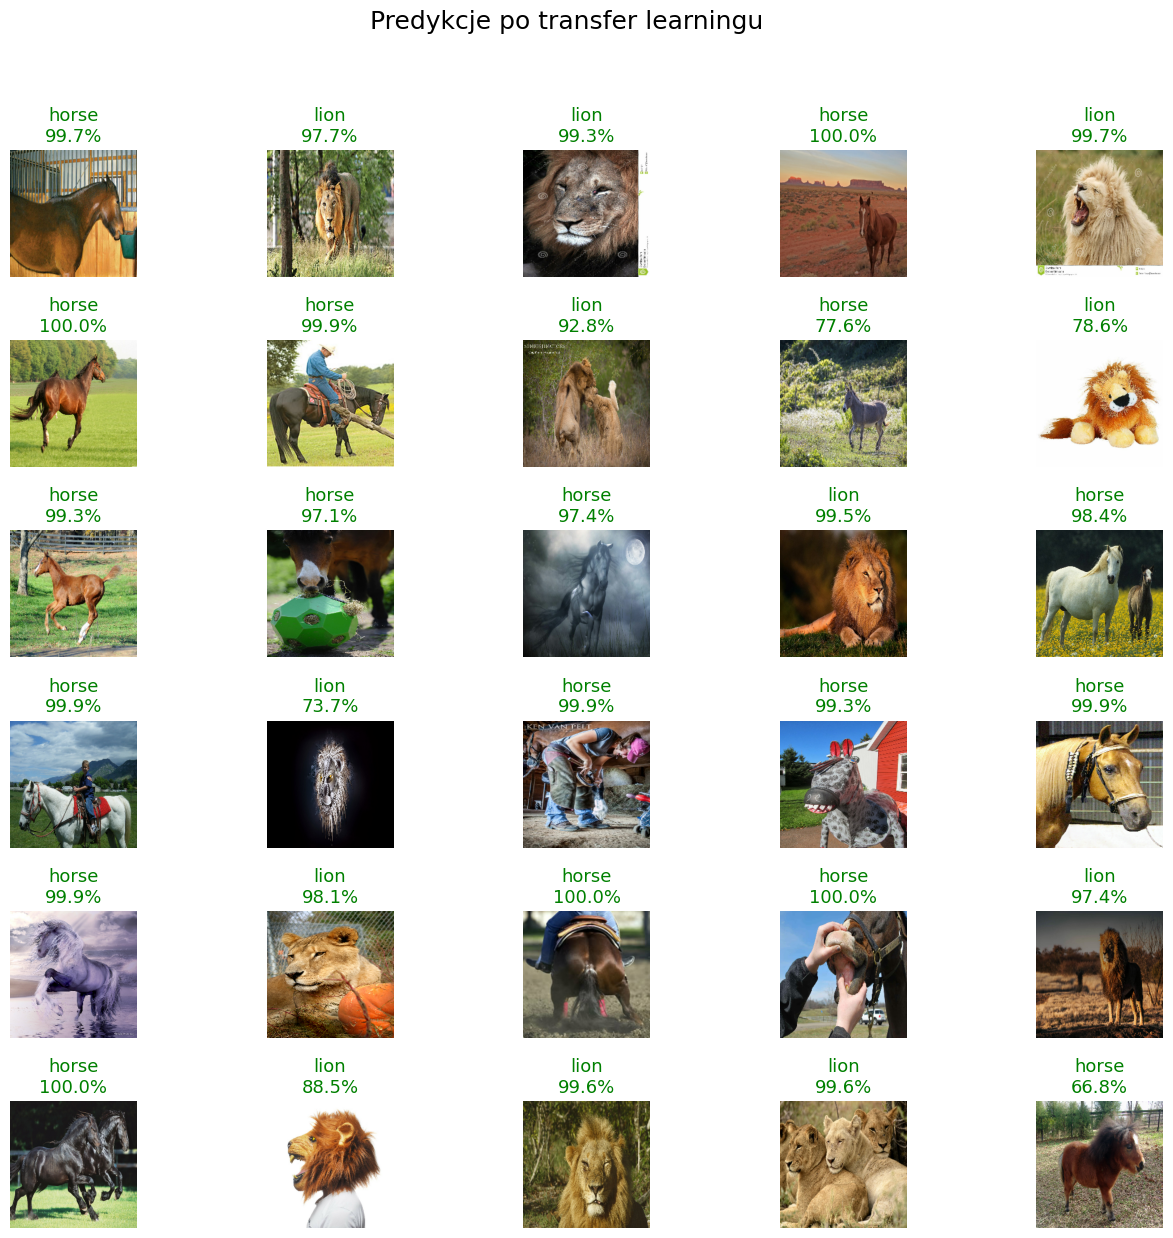

In [24]:
predicted_batch = model.predict(
    image_batch,
    verbose=0
)

predicted_id = np.argmax(
    predicted_batch,
    axis=-1
)

predicted_label_batch = class_names[
    predicted_id
]

label_id = np.argmax(
    label_batch.numpy(),
    axis=-1
)

plt.figure(figsize=(16, 14))
plt.subplots_adjust(hspace=0.5)

n_images = min(30, image_batch.shape[0])

for n in range(n_images):

    plt.subplot(
        6,
        5,
        n + 1
    )

    image_np = image_batch[n].numpy().astype('uint8')

    plt.imshow(image_np)

    color = (
        'green'
        if predicted_id[n] == label_id[n]
        else 'red'
    )

    probability = predicted_batch[n][predicted_id[n]]

    plt.title(
        f'{predicted_label_batch[n]}\n'
        f'{probability * 100:.1f}%',
        color=color,
        fontsize=13
    )

    plt.axis('off')

plt.suptitle(
    'Predykcje po transfer learningu',
    fontsize=18
)

plt.show()

In [25]:
os.makedirs(
    'models',
    exist_ok=True
)

MODEL_PATH = 'models/model_name.keras'

model.save(
    MODEL_PATH
)

print(
    f'[INFO] Model zapisany: {MODEL_PATH}'
)

# Jeżeli potrzebny jest TensorFlow SavedModel do inferencji/serwowania:
# model.export('models/model_name_savedmodel')

[INFO] Model zapisany: models/model_name.keras


### Najważniejsze zmiany względem starego notebooka

- usunięto `%tensorflow_version 2.x`,
- usunięto `tensorflow_hub.KerasLayer`,
- `tensorflow_hub` zastąpiono przez `keras.applications.MobileNetV2`,
- `ImageDataGenerator` zastąpiono przez `keras.utils.image_dataset_from_directory`,
- `flow_from_directory()` zastąpiono przez `tf.data.Dataset`,
- `fit_generator()` zastąpiono przez `model.fit()`,
- poprawiono preprocessing MobileNetV2 do zakresu `[-1, 1]`,
- zastosowano `accuracy` zamiast starej nazwy `acc`,
- `model.save(..., save_format='tf')` zastąpiono natywnym formatem `.keras`,
- pokazano opcjonalne `model.export()` dla formatu SavedModel.

Notebook zachowuje sens oryginalnego ćwiczenia: najpierw wykorzystuje model
wytrenowany na ImageNet do klasyfikacji, a następnie używa MobileNetV2 jako
zamrożonego ekstraktora cech dla własnego zbioru danych.